## 20260814 Adaptive Landscapes 
- this is like a couple of iterations of adaptive landscape generations that I have used. 
- most of this code is AI generated 
- there's a couple of different styles but I will leave the better ones at the top
- gonna try to add a 2d generator soon but also thats like something u can use a real topographical map for 

In [5]:
#import ur things
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps
import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from matplotlib.colors import LightSource

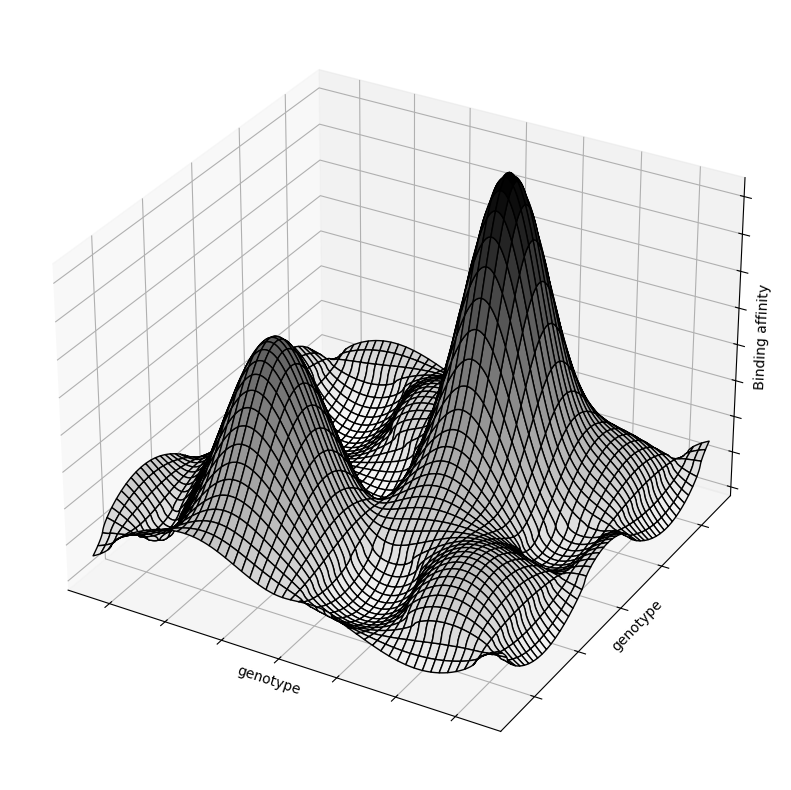

In [ ]:
#this one is the base grid one, but the edges aren't pulled down, i kinda hate seeing the underside of the landscape, kinda cursed
# i think sam likes this one alot 

# Generate a high-resolution grid
x = np.linspace(-7, 7, 400)  # Higher resolution for smoothness
y = np.linspace(-5, 5, 400)
X, Y = np.meshgrid(x, y)
# Define the elevation function with variable peak heights 
#this is how u change ur landscape, you can also get rid od the trig functions if u don't like that rolling aspect but yeah
Z = ((.1 * np.sin(.5*X) * np.cos(.4*Y)) +
     (2 * np.exp(-((X - 2)**2 + (Y - 2)**2) / 2)) + #big peak? 
     (1 * np.exp(-((X + 3)**2 + (Y + 2)**2) / 3)) +
     (0.1 * np.sin(1*X) * np.cos(1*Y)) +  # Medium peaks
     (0 * np.sin(2*X) * np.cos(1*Y)) )   # Smaller peaks #second cos makes the roughness more btw
Z = np.sign(Z) * np.abs(Z) ** 0.7  # Flatten valleys while preserving peak variety
# Normalize Z values for coloring
Z_min, Z_max = Z.min(), Z.max()
norm = (Z - Z_min) / (Z_max - Z_min)  # Normalize between 0 and 1
# Invert the colormap so higher values are darker
colors = cm.binary(norm)  # Using 'Greys_r' for inverted grayscale
# Create the figure
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1,1,1, projection='3d')
#ax.view_init(elev=30, azim=135) #use this to change the angle, kinda funky tho

ax.plot_surface(X, Y, Z,
                cmap="binary",       # continuous grayscale
                edgecolor="k",
                linewidth=1,       #this makes a big difference
                antialiased=True,
                shade=False)          # let matplotlib interpolate lighting

# Remove axes
plt.xticks(color='w')
plt.yticks(color='w')
ax.zaxis.set_tick_params(labelcolor='white')

#ax.set_zticks([])
ax.axis('on')
ax.set_xlabel('genotype', labelpad= -10)
ax.set_ylabel('genotype', labelpad= -10)
ax.set_zlabel('Binding affinity', labelpad= -10)
ax.set_xlim(-7.5,7.5), ax.set_ylim(-5.5,5.5),  ax.set_zlim(-.25,1.5)
# Show the plot
plt.show()

#fig.savefig("FitLandscape_Test.pdf", dpi=300)

#### this is the best one! i love it so much

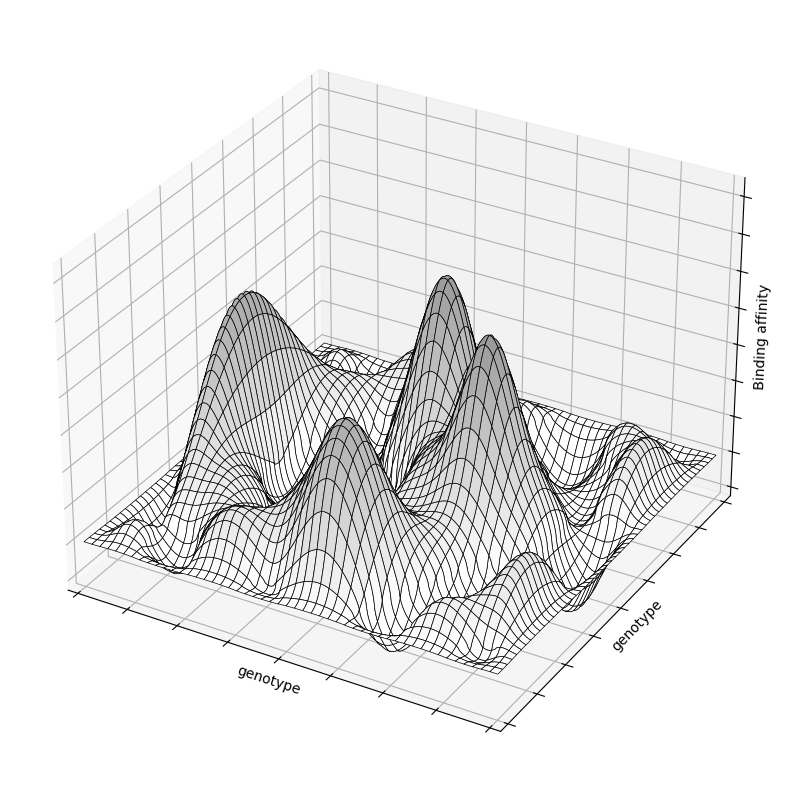

In [ ]:
#best one so far
#This is what I used on my poster, it flattens the edges and i think it looks cleaner
#specify the width and height(other width lol) here 

width=10
otherwidth=8
# Generate a high-resolution grid
x = np.linspace(-width, width, 500)  # Higher resolution for smoothness
y = np.linspace(-otherwidth, otherwidth, 500)
X, Y = np.meshgrid(x, y)
# Define the elevation function with variable peak heights
Z = (0.13*np.sin(0.5*X)*np.cos(0.6*Y) +
     1*np.exp(-((X - 4)**2 + (Y)**2)/2) +  # tall dramatic peak
     1.0*np.exp(-((X)**2 + (Y - 3)**2)/2.5) +  # lower peak 1
     0.85*np.exp(-((X - 1)**2 + (Y + 5)**2)/3.5) +  # lower peak 2
     0.65*np.exp(-(X + 8)**2/1.3)*np.exp(-(Y)**2/16) +  # low ridge on left
     0.1*np.sin(1.25*X)*np.cos(0.85*Y))
# Very gentle falloff - only affects the outer edges
edge_margin_x = 2  # how many units from edge to start dropping
edge_margin_y = 2
#Change the numerator in the fraction to make the edges become more flat, I think 2 is perfect but 2-5 is fine
numerator = 3
edge_falloff_x = np.exp(-np.maximum(0, np.abs(X) - (width - edge_margin_x))**numerator/1.5)
edge_falloff_y = np.exp(-np.maximum(0, np.abs(Y) - (otherwidth - edge_margin_y))**numerator/1.5)
edge_falloff = edge_falloff_x * edge_falloff_y

Z = Z * edge_falloff
Z = np.sign(Z) * np.abs(Z) ** 0.7  # Flatten valleys while preserving peak variety
# Normalize Z values for coloring
Z_min, Z_max = Z.min(), Z.max()
norm = (Z - Z_min) / (Z_max - Z_min)  # Normalize between 0 and 1
# Create the figure
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1,1,1, projection='3d')
#ax.view_init(elev=30, azim=135) #use this to change the angle, kinda funky tho

ax.plot_surface(X, Y, Z,
                cmap="binary",       # continuous grayscale
                vmin=-0,
                vmax= 2.5,
                edgecolor="k",
                linewidth=.5,
                antialiased=True,
                shade=False)          # let matplotlib interpolate lighting

# Remove axes
plt.xticks(color='w')
plt.yticks(color='w')
ax.zaxis.set_tick_params(labelcolor='white')

#ax.set_zticks([])
ax.axis('on')
ax.set_xlabel('genotype', labelpad= -10)
ax.set_ylabel('genotype', labelpad= -10)
ax.set_zlabel('Binding affinity', labelpad= -10)
ax.set_xlim(-width-.5,width+.5), ax.set_ylim(-otherwidth-.5,otherwidth+.5),  ax.set_zlim(-.25,1.5)
# Show the plot
plt.show()

#fig.savefig("FitLandscape_binary_evenpeaks.pdf", dpi=500)

Here are funkier ones that I tried to use during lab meeting but tbh thats the only real use for them, its mainly the same functions but playing with colors and shapes

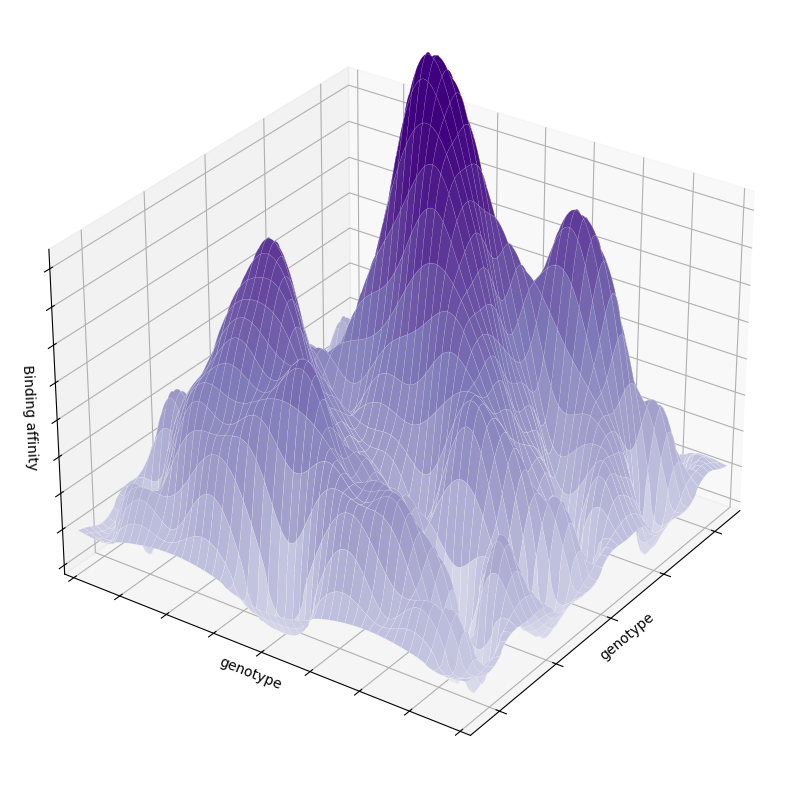

In [22]:
#realistic mountains 
width=12
otherwidth=10
# Generate a high-resolution grid
x = np.linspace(-width, width, 500)  # Higher resolution for smoothness
y = np.linspace(-otherwidth, otherwidth, 500)
X, Y = np.meshgrid(x, y)
# Define the elevation function with variable peak heights
Z = (# Tall broad peak
     3.0 * np.exp(-((X - 1)**2 + (Y + 1)**2) / 10) +
     # Medium peak - back left
     1.8 * np.exp(-((X + 6)**2 + (Y - 4)**2) / 8) +
     # Smaller peak - front right
     1.3 * np.exp(-((X - 6)**2 + (Y + 5)**2) / 7) +
     # Low ridge on left edge
     0.7 * np.exp(-(X + 9)**2 / 3) * np.exp(-(Y)**2 / 18) +
     # Mid-height bumps to fill the valleys
     0.5 * np.exp(-((X - 4)**2 + (Y - 3)**2) / 4) +
     0.45 * np.exp(-((X + 2)**2 + (Y + 5)**2) / 5) +
     0.4 * np.exp(-((X - 3)**2 + (Y - 6)**2) / 3.5) +
     0.35 * np.exp(-((X + 8)**2 + (Y + 4)**2) / 4) +
     # Rougher base undulation
     0.3 * np.sin(0.7*X) * np.cos(0.6*Y) +
     0.2 * np.sin(1.3*X) * np.cos(1.1*Y) +
     0.1 * np.sin(2.1*X) * np.cos(1.8*Y))
# Very gentle falloff - only affects the outer edges
edge_margin_x = 2  # how many units from edge to start dropping
edge_margin_y = 2
edge_falloff_x = np.exp(-np.maximum(0, np.abs(X) - (width - edge_margin_x))**2/1.5)
edge_falloff_y = np.exp(-np.maximum(0, np.abs(Y) - (otherwidth - edge_margin_y))**2/1.5)
edge_falloff = edge_falloff_x * edge_falloff_y

Z = Z * edge_falloff
Z = np.sign(Z) * np.abs(Z) ** 0.7  # Flatten valleys while preserving peak variety
# Normalize Z values for coloring
Z_min, Z_max = Z.min(), Z.max()
norm = (Z - Z_min) / (Z_max - Z_min)  # Normalize between 0 and 1
# Invert the colormap so higher values are darker
colors = cm.binary(norm)  # Using 'Greys_r' for inverted grayscale
# Create the figure
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1,1,1, projection='3d')
ax.view_init(elev=30, azim=215) #use this to change the angle, kinda funky tho
ax.plot_surface(X, Y, Z,
                cmap="Purples",       # continuous grayscale
                vmin=-1,
                vmax= 2,
                edgecolor="white",
                linewidth=.1,
                antialiased=True,
                shade=False)          # let matplotlib interpolate lighting

# Remove axes
plt.xticks(color='w')
plt.yticks(color='w')
ax.zaxis.set_tick_params(labelcolor='white')

#ax.set_zticks([])
ax.axis('on')
ax.set_xlabel('genotype', labelpad= -10)
ax.set_ylabel('genotype', labelpad= -10)
ax.set_zlabel('Binding affinity', labelpad= -10)
ax.set_xlim(-width-.5,width+.5), ax.set_ylim(-otherwidth-.5,otherwidth+.5),  ax.set_zlim(-.25,1.5)
# Show the plot
plt.show()

#fig.savefig("FitLandscape_Purple_blacklines.pdf", dpi=500)

ngl ^^ this one kinda looks beautiful 

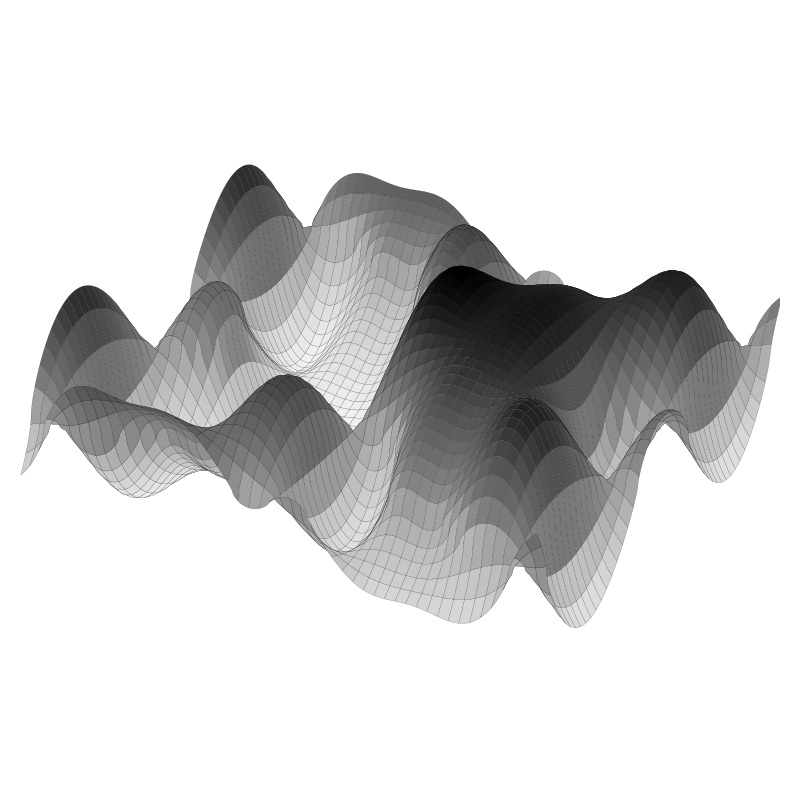

In [27]:
#this was when i didn't beleive in axis, but that ship has sailed, i had a similar landscape to this on my first poster

# Generate a high-resolution grid
x = np.linspace(-7, 7, 1000)  # Higher resolution for smoothness
y = np.linspace(-5, 5, 1000)
X, Y = np.meshgrid(x, y)
# Define the elevation function with variable peak heights
Z = (np.sin(.5*X) * np.cos(.4*Y) +
     0.5 * np.sin(1*X) * np.cos(1*Y) +  # Medium peaks
     0.3 * np.sin(2*X) * np.cos(1*Y))   # Smaller peaks #second cos makes the roughness more btw
Z = np.sign(Z) * np.abs(Z) ** 0.7  # Flatten valleys while preserving peak variety
# Normalize Z values for coloring
Z_min, Z_max = Z.min(), Z.max()
norm = (Z - Z_min) / (Z_max - Z_min)  # Normalize between 0 and 1
# Invert the colormap so higher values are darker
colors = cm.Greys(norm)  # Using 'Greys_r' for inverted grayscale
# Create the figure
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1,1,1, projection='3d')
#ax.view_init(elev=30, azim=135)
# Plot the surface with custom coloring and smoothing
ax.plot_surface(X, Y, Z, 
                facecolors=colors, 
                edgecolor='k', #can also use none which is decent
                linewidth=.1,
                antialiased=True, 
                shade=False)


# Remove axes
plt.xticks(color='w')
plt.yticks(color='w')
#ax.set_xticks([])
#ax.set_yticks([])
ax.set_zticks([])
ax.axis('off')
ax.set_xlim(-6,6), ax.set_ylim(-4.75,4.75),  ax.set_zlim(-1.50,1.5)
# Show the plot
plt.show()

#fig.savefig("FitLandscape_Grey.pdf", dpi=300)